In [1]:
!pip install imbalanced-learn


Kích thước train: (809, 13) | Phân bố: Counter({0: 800, 1: 9})
Kích thước val: (4060, 13) | Phân bố: Counter({0: 4000, 1: 60})
Kích thước test: (6090, 13) | Phân bố: Counter({0: 6000, 1: 90})

Phân bố train sau map: Counter({0: 800, 1: 9})
Phân bố val sau map: Counter({0: 4000, 1: 60})
Phân bố test sau map: Counter({0: 6000, 1: 90})

Các cột trong X_train:
['Source', 'Length', 'stNum', 'sqNum', 'goID', 'heartbeat', 'dif_stNum', 'dif_sqNum', 'Circuit breaker Open/Close Status', 'I-high VT', 'I-high VT- Tran', 'I-low VT- Tran', 'I-amongst-feeders']

X_train_proc shape: (809, 90)
X_val_proc shape: (4060, 90)
X_test_proc shape: (6090, 90)

[Correlation Filter] Số feature ban đầu: 90
[Correlation Filter] Số feature bị drop: 5
[Correlation Filter] Số feature giữ lại: 85

=== Data balancing với SMOTE + RandomUnderSampler (chỉ trên TRAIN) ===
Trước balancing: Counter({np.int64(0): 800, np.int64(1): 9})
Sau balancing: Counter({np.int64(0): 800, np.int64(1): 800})

=== Huấn luyện KNN với GridSe

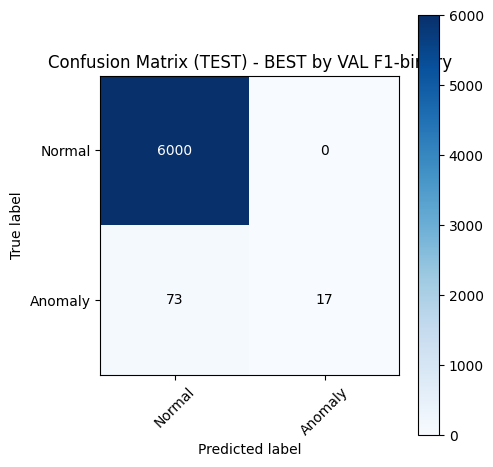

In [2]:
# ============================================================
# KNN SUPERVISED CHO DATA GOOSE THEO PHƯƠNG PHÁP ML-ADS PAPER
# (GIỮ NGUYÊN TẤT CẢ hyperparameter/param_grid/cv/scoring...)
# CHỈ THAY ĐỔI:
#   (1) Chọn model có BEST F1-score (BINARY, pos_label=1) trên VALIDATION
#   (2) In ra: F1-binary, AUROC, MCC (VAL + TEST)
#   (3) Vẽ confusion matrix (TEST) cho best model
# ============================================================

import math
import random
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --------------------------
# 0) Thiết lập matplotlib
# --------------------------
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.use_locale'] = False
mpl.rcParams['axes.formatter.use_mathtext'] = False

# --------------------------
# 1) Thiết lập SEED (GIỮ NGUYÊN)
# --------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ---------------------------
# 2) Load CSVs (GIỮ NGUYÊN)
# ---------------------------
train_df = pd.read_csv("label_pool.csv")
val_df   = pd.read_csv("val_labeled_40.csv")
test_df  = pd.read_csv("test_labeled_60.csv")

FEATURES = [c for c in train_df.columns if c != "Label"]
X_train, y_train = train_df[FEATURES], train_df["Label"]
X_val,   y_val   = val_df[FEATURES],   val_df["Label"]
X_test,  y_test  = test_df[FEATURES],  test_df["Label"]

print("\nKích thước train:", X_train.shape, "| Phân bố:", Counter(y_train))
print("Kích thước val:",   X_val.shape,   "| Phân bố:", Counter(y_val))
print("Kích thước test:",  X_test.shape,  "| Phân bố:", Counter(y_test))

# Map label string -> 0/1 nếu cần (GIỮ NGUYÊN)
if y_train.dtype == object:
    label_mapping = {lab: i for i, lab in enumerate(sorted(y_train.unique()))}
    print("Mapping Label:", label_mapping)
    y_train = y_train.map(label_mapping)
    y_val   = y_val.map(label_mapping)
    y_test  = y_test.map(label_mapping)

print("\nPhân bố train sau map:", Counter(y_train))
print("Phân bố val sau map:",   Counter(y_val))
print("Phân bố test sau map:",  Counter(y_test))

# --------------------------
# 3) Preprocess (GIỮ NGUYÊN)
# --------------------------
print("\nCác cột trong X_train:")
print(list(X_train.columns))

num_transformer = Pipeline(steps=[("num_scaler", MinMaxScaler())])

ord_cols = []
if "Circuit breaker Open/Close Status" in X_train.columns:
    ord_cols = ["Circuit breaker Open/Close Status"]
    cb_levels = [np.sort(X_train['Circuit breaker Open/Close Status'].unique()).tolist()]
    ord_transformer = Pipeline(steps=[
        ("encoder", OrdinalEncoder(
            categories=cb_levels,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ])
else:
    ord_transformer = None

nom_cols = [c for c in ['stNum', 'Source', 'dif_stNum', 'dif_sqNum', 'goID']
            if c in X_train.columns]
nom_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

transformers = []
num_cols = [c for c in ['Length', 'heartbeat', 'I-high VT',
                        'I-high VT- Tran', 'I-low VT- Tran',
                        'I-amongst-feeders', 'sqNum']
            if c in X_train.columns]
if len(num_cols) > 0:
    transformers.append(("num_feature", num_transformer, num_cols))
if ord_transformer is not None and len(ord_cols) > 0:
    transformers.append(("ord_feature", ord_transformer, ord_cols))
if len(nom_cols) > 0:
    transformers.append(("nom_feature", nom_transformer, nom_cols))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
reg = Pipeline(steps=[("preprocessor", preprocessor)])

reg.fit(X_train)
X_train_proc = reg.transform(X_train)
X_val_proc   = reg.transform(X_val)
X_test_proc  = reg.transform(X_test)

print("\nX_train_proc shape:", X_train_proc.shape)
print("X_val_proc shape:",   X_val_proc.shape)
print("X_test_proc shape:",  X_test_proc.shape)

# --------------------------
# 4) Correlation filter (GIỮ NGUYÊN)
# --------------------------
def apply_correlation_filter(X_train_np, threshold=0.95):
    df = pd.DataFrame(X_train_np)
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    keep_idx = [i for i in range(df.shape[1]) if i not in to_drop]

    print(f"\n[Correlation Filter] Số feature ban đầu: {df.shape[1]}")
    print(f"[Correlation Filter] Số feature bị drop: {len(to_drop)}")
    print(f"[Correlation Filter] Số feature giữ lại: {len(keep_idx)}")

    X_train_f = df.iloc[:, keep_idx].to_numpy()
    return X_train_f, keep_idx

X_train_np_full = X_train_proc.astype(np.float32)
X_train_sel, keep_indices = apply_correlation_filter(X_train_np_full, threshold=0.95)

X_val_sel  = pd.DataFrame(X_val_proc).iloc[:, keep_indices].to_numpy().astype(np.float32)
X_test_sel = pd.DataFrame(X_test_proc).iloc[:, keep_indices].to_numpy().astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.int64)
y_val_np   = y_val.to_numpy().astype(np.int64)
y_test_np  = y_test.to_numpy().astype(np.int64)

num_classes = len(np.unique(y_train_np))

# --------------------------
# 5) SMOTE + RUS (GIỮ NGUYÊN)
# --------------------------
print("\n=== Data balancing với SMOTE + RandomUnderSampler (chỉ trên TRAIN) ===")
print("Trước balancing:", Counter(y_train_np))

smote = SMOTE(random_state=SEED)
X_res, y_res = smote.fit_resample(X_train_sel, y_train_np)

rus = RandomUnderSampler(random_state=SEED)
X_bal, y_bal = rus.fit_resample(X_res, y_res)

print("Sau balancing:", Counter(y_bal))

# --------------------------
# 6) GridSearchCV (GIỮ NGUYÊN TẤT CẢ)
# --------------------------
print("\n=== Huấn luyện KNN với GridSearchCV (10-fold CV, scoring=F1_macro) ===")

param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski"],
}

base_knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator=base_knn,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_bal, y_bal)

print("\nBest params từ GridSearchCV (theo CV f1_macro - giữ nguyên):", grid_search.best_params_)
print("Best CV F1_macro (giữ nguyên):", grid_search.best_score_)

# ============================================================
# (CHỈ THAY ĐỔI #1) PICK BEST MODEL THEO VAL F1-BINARY
# ============================================================
best_val_f1_binary = -1.0
best_params_val = None
best_knn = None

for params in grid_search.cv_results_["params"]:
    knn = KNeighborsClassifier(**params)
    knn.fit(X_bal, y_bal)

    val_pred_tmp = knn.predict(X_val_sel)
    f1_bin_tmp = f1_score(y_val_np, val_pred_tmp, average="binary", pos_label=1, zero_division=0)

    if f1_bin_tmp > best_val_f1_binary:
        best_val_f1_binary = f1_bin_tmp
        best_params_val = params
        best_knn = knn

print("\n✅ Best params theo VAL F1-binary:", best_params_val)
print("✅ Best VAL F1-binary:", best_val_f1_binary)

# ============================================================
# (CHỈ THAY ĐỔI #2) IN RA: F1-binary, AUROC, MCC (VAL + TEST)
# ============================================================
def compute_3_metrics_binary(model, X, y):
    y = y.astype(int)
    pred = model.predict(X)

    f1_bin = f1_score(y, pred, average="binary", pos_label=1, zero_division=0)
    mcc = matthews_corrcoef(y, pred) if len(np.unique(y)) > 1 else 0.0

    try:
        scores = model.predict_proba(X)[:, 1]
        auroc = roc_auc_score(y, scores) if len(np.unique(y)) > 1 else float("nan")
    except Exception:
        auroc = float("nan")

    return f1_bin, auroc, mcc, pred

# ---- VALIDATION ----
val_f1_bin, val_auroc, val_mcc, val_pred = compute_3_metrics_binary(best_knn, X_val_sel, y_val_np)

print("\n=== METRICS (VALIDATION - BEST theo F1-binary) ===")
print(f"VAL F1-binary = {val_f1_bin:.4f}")
print(f"VAL AUROC     = {(val_auroc*100 if val_auroc==val_auroc else float('nan')):.3f}%")
print(f"VAL MCC       = {val_mcc:.4f}")

# ---- TEST ----
test_f1_bin, test_auroc, test_mcc, test_pred = compute_3_metrics_binary(best_knn, X_test_sel, y_test_np)

print("\n=== METRICS (TEST - BEST theo VAL F1-binary) ===")
print(f"TEST F1-binary = {test_f1_bin:.4f}")
print(f"TEST AUROC     = {(test_auroc*100 if test_auroc==test_auroc else float('nan')):.3f}%")
print(f"TEST MCC       = {test_mcc:.4f}")

# ============================================================
# (CHỈ THAY ĐỔI #3) VẼ CONFUSION MATRIX (TEST)
# ============================================================
cm = confusion_matrix(y_test_np, test_pred)

print("\n=== CONFUSION MATRIX (TEST) ===")
print(cm)

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix (TEST) - BEST by VAL F1-binary")
plt.colorbar()

class_names = ["Normal", "Anomaly"] if num_classes == 2 else [str(i) for i in range(num_classes)]
tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.0 if cm.max() > 0 else 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()
